# 03 Hybrid

Hybrid pipeline: RL proposal -> feasibility layer -> GLS refinement.

In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.dynamic.dynamic_instance import DynamicInstance
from dvrptw_bench.dynamic.simulator import DynamicSimulator
from dvrptw_bench.hybrid.hybrid_runner import run_hybrid_with_solver_fn
from dvrptw_bench.hybrid.feasibility_layer import FeasibilityLayer
from dvrptw_bench.common.typing import Route, Solution
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.rl.policies import build_policy
from dvrptw_bench.viz.dashboard import render_dashboard
import torch
from dvrptw_bench.dynamic.dynamic_instance import DynamicInstance
from dvrptw_bench.heuristics.ortools_dynamic import ORToolsDVRPTWSolver
from dvrptw_bench.metrics.objective import total_distance
from dvrptw_bench.rl.routefinder_model import build_routefinder_model
from dvrptw_bench.rl.routefinder_policy import RouteFinderAdapterPolicy
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.metrics.objective import total_distance
from dvrptw_bench.rl.routefinder_adapter import instance_to_routefinder_td, routefinder_actions_to_solution
from dvrptw_bench.rl.mtvrp_solomon_generator import SolomonMTVRPGenerator
from dvrptw_bench.rl.mtvrp_solomon_generator import MTVRPGenerator
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.common.typing import VRPTWInstance
from routefinder.envs.mtvrp import MTVRPEnv, MTVRPGenerator
from routefinder.models import RouteFinderBase, RouteFinderPolicy
from routefinder.utils import evaluate as evaluate_routefinder

In [7]:
NUM_CUSTOMERS = 100
NUM_EPOCHS = 3
BATCH_SIZE = 256
TRAIN_DATA_SIZE = 1000
VAL_DATA_SIZE = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-6
NUM_AUGMENT = 8
ORTOOLS_TIME_LIMIT_S = 1
MAX_EVAL_INSTANCES = 5  # set to None to evaluate all RC instances
NORMALIZE_COORDS = True # whether to normalize coordinates to [0, 1] when creating RouteFinder training data
EPSILON = 0.4
BUDGET_S = ORTOOLS_TIME_LIMIT_S
SEED = 7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset_root = Path('../dataset')
instances = find_rc_instances(dataset_root)
print(instances)
print(f"Found {len(instances)} RC instances.")
assert instances, 'Place RC*.txt files under ../dataset/solomon_rc100/'
instance = parse_solomon(instances[0], max_customers=NUM_CUSTOMERS)
instance.instance_id

[PosixPath('../dataset/solomon_rc100/RC201.txt'), PosixPath('../dataset/solomon_rc100/RC202.txt'), PosixPath('../dataset/solomon_rc100/RC203.txt'), PosixPath('../dataset/solomon_rc100/RC204.txt'), PosixPath('../dataset/solomon_rc100/RC205.txt'), PosixPath('../dataset/solomon_rc100/RC206.txt'), PosixPath('../dataset/solomon_rc100/RC207.txt'), PosixPath('../dataset/solomon_rc100/RC208.txt')]
Found 8 RC instances.


'RC201.txt'

## RouteFinder setup + dynamic hybrid smoke test

In [8]:



generator = MTVRPGenerator(num_loc=NUM_CUSTOMERS, max_time=10.11,variant_preset='vrptw')
env = MTVRPEnv(generator, check_solution=False)
policy = RouteFinderPolicy(env_name=env.name).to(device)
model = RouteFinderBase(
    env,
    policy,
    batch_size=BATCH_SIZE,
    train_data_size=TRAIN_DATA_SIZE,
    val_data_size=VAL_DATA_SIZE,
    optimizer_kwargs={'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
)
# model = build_routefinder_model(checkpoint_path="../trained_models/solomon_generated_50_working.ckpt")
routefinder_policy = RouteFinderAdapterPolicy()
routefinder_policy.load("../trained_models/solomon_generated_50_working.ckpt", device=torch.device('cpu'), normalize_coords=NORMALIZE_COORDS, variant_preset='vrptw')
# RouteFinder policy is used as the AI proposal stage for the dynamic simulator.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/accelerator_connector.py:479: You passed `Trainer(accelerator='cpu', precision='16-mixed')` but AMP with fp16 is not supported on CPU. Using `precision='bf16-mixed'` instead.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: T

In [9]:
import time


sim = DynamicSimulator(instance)
ortools_solver = ORToolsDVRPTWSolver(soft_time_windows=True)

def solve_with_routefinder(instance: VRPTWInstance, num_augment=NUM_AUGMENT):
    t0 = time.perf_counter()
    solution = routefinder_policy.infer_instance(
        instance,
        num_augment=num_augment,
    )
    solution.total_distance = total_distance(instance, solution)
    solution.solve_time_s = time.perf_counter() - t0
    solution.details.update({'num_augment': num_augment})
    return solution

def routefinder_solver_fn(instance, time_limit_s, warm_start=None):
    return solve_with_routefinder(instance)

def dynamic_hybrid_solver(instance : DynamicInstance, time_limit_s : int, warm_start=None):
    sol, _ = run_hybrid_with_solver_fn(
        instance=instance,
        solver_fn=routefinder_solver_fn,
        budget_s=time_limit_s,
        gls_time_share=0.9,
        feasibility_mode='repair',
    )
    return sol


## Dynamic comparison: OR-Tools vs RouteFinder (AI only) vs Hybrid
Run the same dynamic simulator configuration for all three strategies and compare key metrics with plots.

CUstomers length: 100, n_dyn: 40, dynamic_ids: [1, 4, 10, 11, 16, 21, 22, 24, 25, 29, 34, 38, 39, 40, 43, 44, 46, 48, 51, 52, 54, 56, 58, 61, 62, 63, 64, 67, 68, 75, 76, 77, 78, 80, 81, 86, 87, 94, 96, 99]
CUstomers length: 100, n_dyn: 40, dynamic_ids: [1, 4, 10, 11, 16, 21, 22, 24, 25, 29, 34, 38, 39, 40, 43, 44, 46, 48, 51, 52, 54, 56, 58, 61, 62, 63, 64, 67, 68, 75, 76, 77, 78, 80, 81, 86, 87, 94, 96, 99]
service_start: 162, c.due_time: 153.0, completion_time: 172, lateness: 9.0
Customer 42 is late.
service_start: 199, c.due_time: 184.0, completion_time: 209, lateness: 15.0
Customer 39 is late.
service_start: 184, c.due_time: 159.0, completion_time: 194, lateness: 25.0
Customer 63 is late.
service_start: 295, c.due_time: 162.0, completion_time: 305, lateness: 133.0
Customer 59 is late.
service_start: 318, c.due_time: 294.0, completion_time: 328, lateness: 24.0
Customer 15 is late.
service_start: 384, c.due_time: 315.0, completion_time: 394, lateness: 69.0
Customer 11 is late.
servic

,feasible,total_distance,num_vehicles,customers_served,customers_rejected,rejection_rate,solve_time_s,num_events
solver,,,,,,,,
ortools,True,1486.0,13,100,0,0.0,0.0,40
ai_only_routefinder,False,7153.0,16,100,0,0.0,0.0,40
hybrid_routefinder_ortools,False,1472.0,11,100,0,0.0,0.0,40


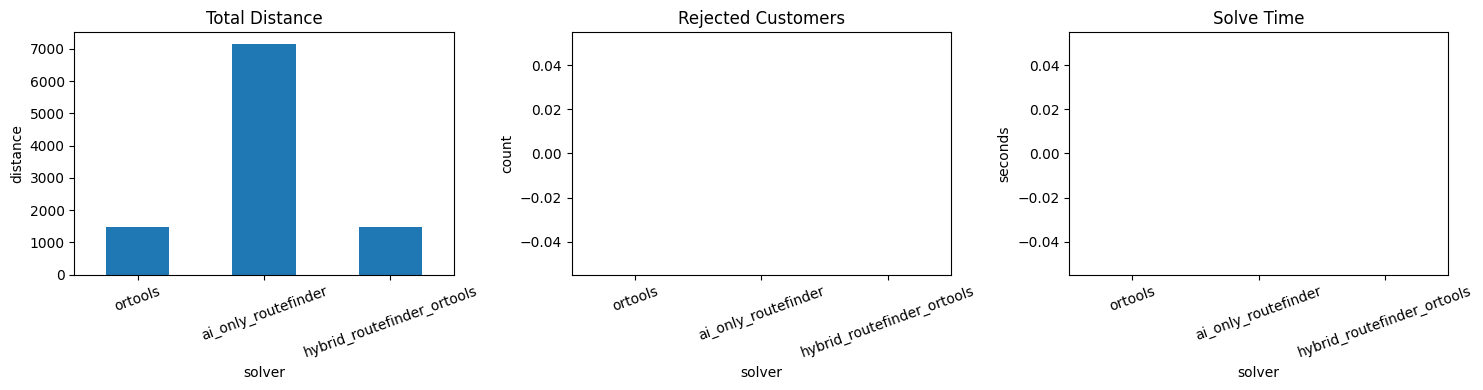

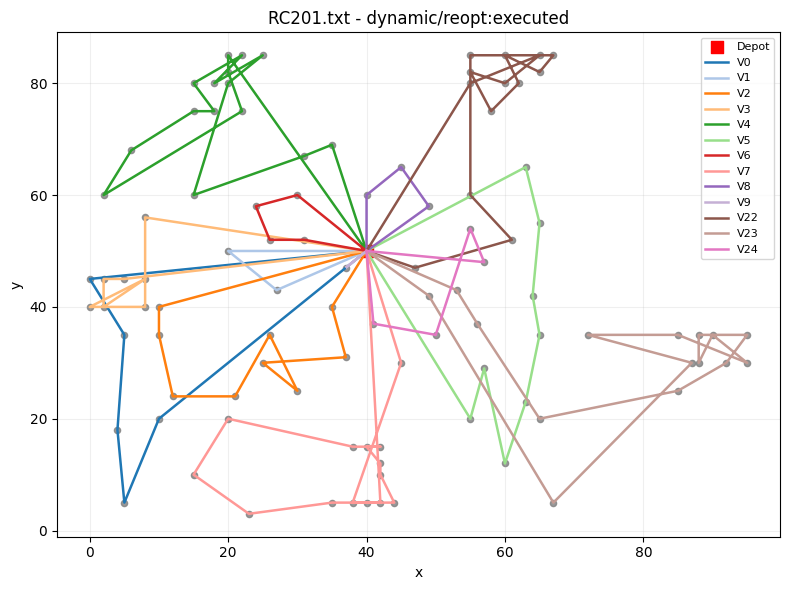

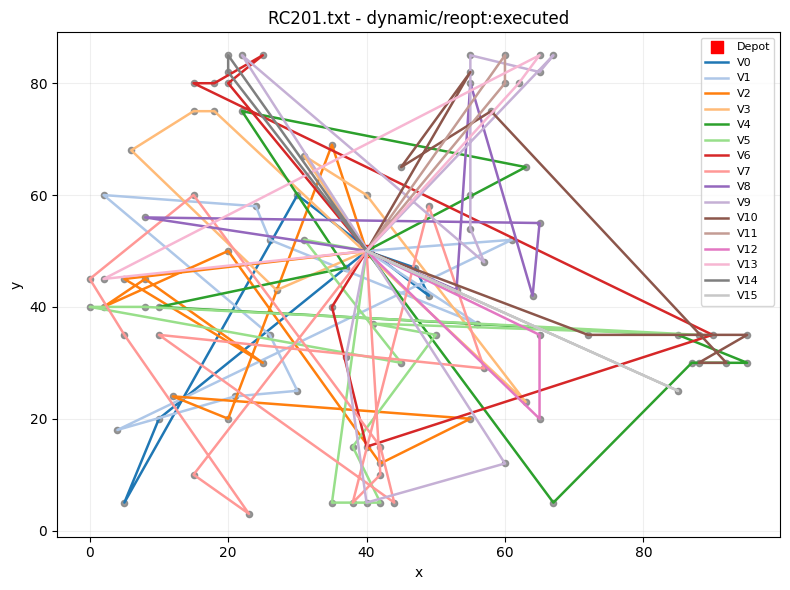

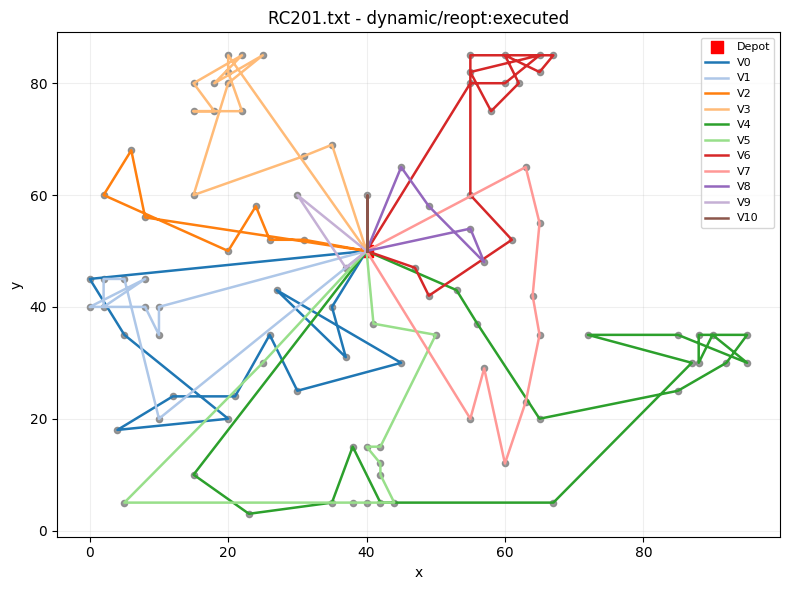

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from dvrptw_bench.heuristics.ortools_dynamic import ORToolsDVRPTWSolver

def ortools_dynamic_solver(instance, time_limit_s, warm_start=None):
    solver = ortools_solver
    return solver.solve(instance=instance, time_limit_s=time_limit_s, warm_start=warm_start)

def ai_only_solver(instance, time_limit_s, warm_start=None):
    _ = warm_start
    return routefinder_solver_fn(instance, time_limit_s, warm_start=None)

def hybrid_solver(instance, time_limit_s, warm_start=None):
    _ = warm_start
    sol, _ = run_hybrid_with_solver_fn(
        instance=instance,
        solver_fn=routefinder_solver_fn,
        budget_s=time_limit_s,
        gls_time_share=0.9,
        feasibility_mode='repair',
    )
    return sol

def summarize_solution(name, sol, events):
    if sol is None:
        return {
            'solver': name,
            'feasible': False,
            'total_distance': float('nan'),
            'num_vehicles': 0,
            'customers_served': 0,
            'customers_rejected': len(instance.customers),
            'rejection_rate': 1.0,
            'solve_time_s': float('nan'),
            'num_events': len(events),
        }

    served = sorted({nid for r in sol.routes for nid in r.node_ids})
    total_customers = len(instance.customers)
    rejected = total_customers - len(served)
    return {
        'solver': name,
        'feasible': bool(getattr(sol, 'feasible', True)),
        'total_distance': float(sol.total_distance),
        'num_vehicles': len([r for r in sol.routes if r.node_ids]),
        'customers_served': len(served),
        'customers_rejected': rejected,
        'rejection_rate': rejected / max(1, total_customers),
        'solve_time_s': float(getattr(sol, 'solve_time_s', 0.0)),
        'num_events': len(events),
    }

def run_dynamic_once(name, solver_fn, epsilon=0.3, budget_s=1.0, seed=7):
    sim_local = DynamicSimulator(instance)
    sol, events, scenario = sim_local.run(
        solver_fn=solver_fn,
        epsilon=epsilon,
        budget_s=budget_s,
        seed=seed,
    )
    return summarize_solution(name, sol, events), sol, events, scenario


rows = []
solutions = {}
event_logs = {}

for name, solver_fn in [
    ('ortools', ortools_dynamic_solver),
    ('ai_only_routefinder', ai_only_solver),
    ('hybrid_routefinder_ortools', hybrid_solver),
]:
    row, sol, events, scenario = run_dynamic_once(
        name=name,
        solver_fn=solver_fn,
        epsilon=EPSILON,
        budget_s=BUDGET_S,
        seed=SEED,
    )
    rows.append(row)
    solutions[name] = sol
    event_logs[name] = events

comparison_df = pd.DataFrame(rows).set_index('solver')
display(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison_df['total_distance'].plot(kind='bar', ax=axes[0], title='Total Distance')
axes[0].set_ylabel('distance')
comparison_df['customers_rejected'].plot(kind='bar', ax=axes[1], title='Rejected Customers', color='tomato')
axes[1].set_ylabel('count')
comparison_df['solve_time_s'].plot(kind='bar', ax=axes[2], title='Solve Time')
axes[2].set_ylabel('seconds')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# Plot final route solutions for each strategy on the same instance.
for solver_name, sol in solutions.items():
    if sol is None:
        print(f'{solver_name}: no solution returned')
        continue
    _ = plot_routes(instance, sol)
    plt.show()